# HOMEWORK 9

> In this homework, you are going to use the dlib face detector and apply it to an image of your liking. <br/>
> You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-) <br/>
> For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [1]:
import cv2
import matplotlib.pyplot as plt

from RobotDreams.lesson_9.homework.solution.utils import (
    HaarDetector,
    OpenCVDnnFaceDetector,
    YunetFaceDetector,
)

plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

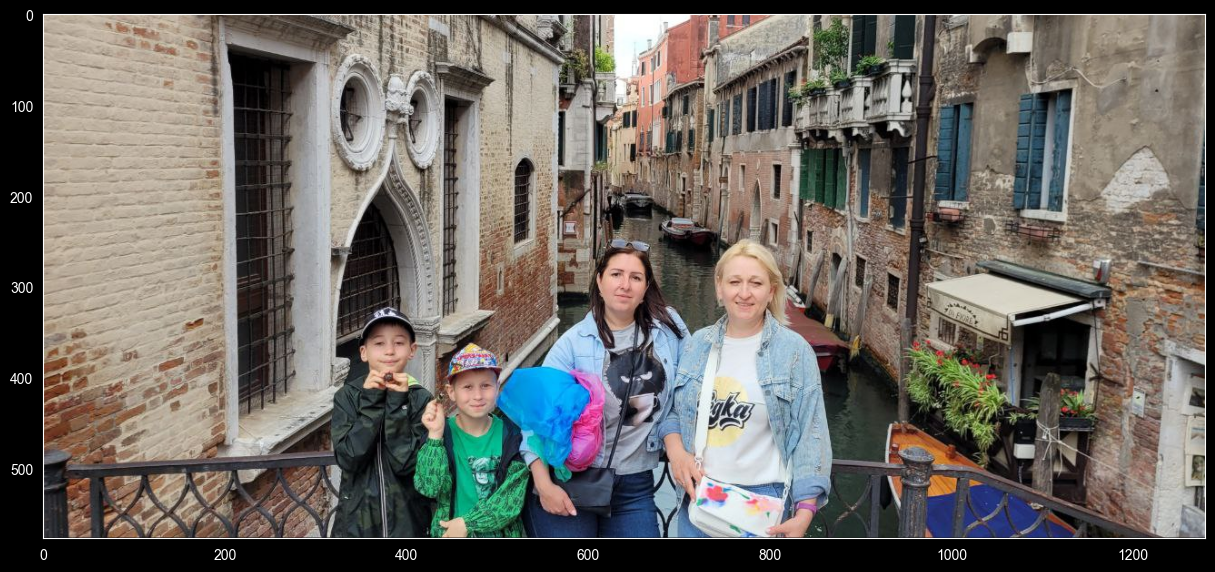

In [2]:
path = '../../../images/Venezia.jpg'
venice_bgr_img = cv2.imread(path, cv2.IMREAD_COLOR)
venice_rgb_img = cv2.cvtColor(venice_bgr_img, cv2.COLOR_BGR2RGB)
venice_gray = cv2.cvtColor(venice_rgb_img, cv2.COLOR_RGB2GRAY)

plt.imshow(venice_rgb_img)
plt.grid(False)

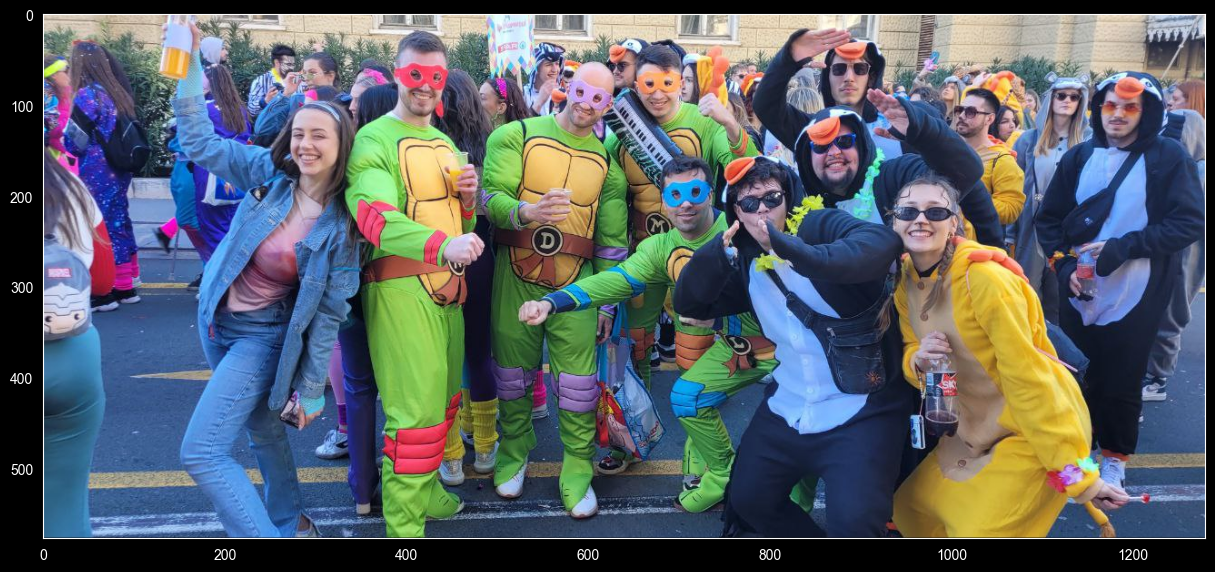

In [3]:
path = '../../../images/Rijeka Karnaval.jpg'

karnaval_bgr_img = cv2.imread(path, cv2.IMREAD_COLOR)
karnaval_rgb_img = cv2.cvtColor(karnaval_bgr_img, cv2.COLOR_BGR2RGB)
karnaval_gray = cv2.cvtColor(karnaval_rgb_img, cv2.COLOR_RGB2GRAY)

plt.imshow(karnaval_rgb_img)
plt.grid(False)


### Step 2

Load the dlib face predictor.

### Step 3

Run the predictor on your image.

In [4]:
haar_detector = HaarDetector()(venice_rgb_img)

Number of detected faces: 4


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

In [5]:
haar_detector.out

[(452, 391, 53, 53),
 (355, 342, 53, 53),
 (610, 265, 61, 61),
 (738, 270, 68, 68)]

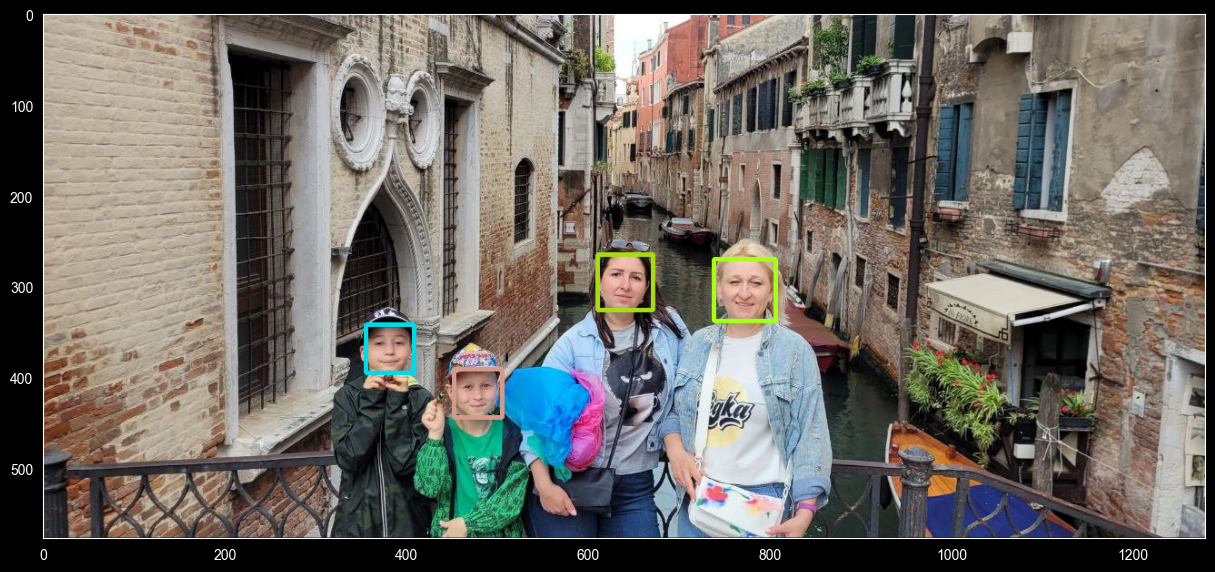

In [6]:
result = haar_detector.draw_faces()

plt.imshow(result)
plt.grid(False)

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Number of detected faces: 4


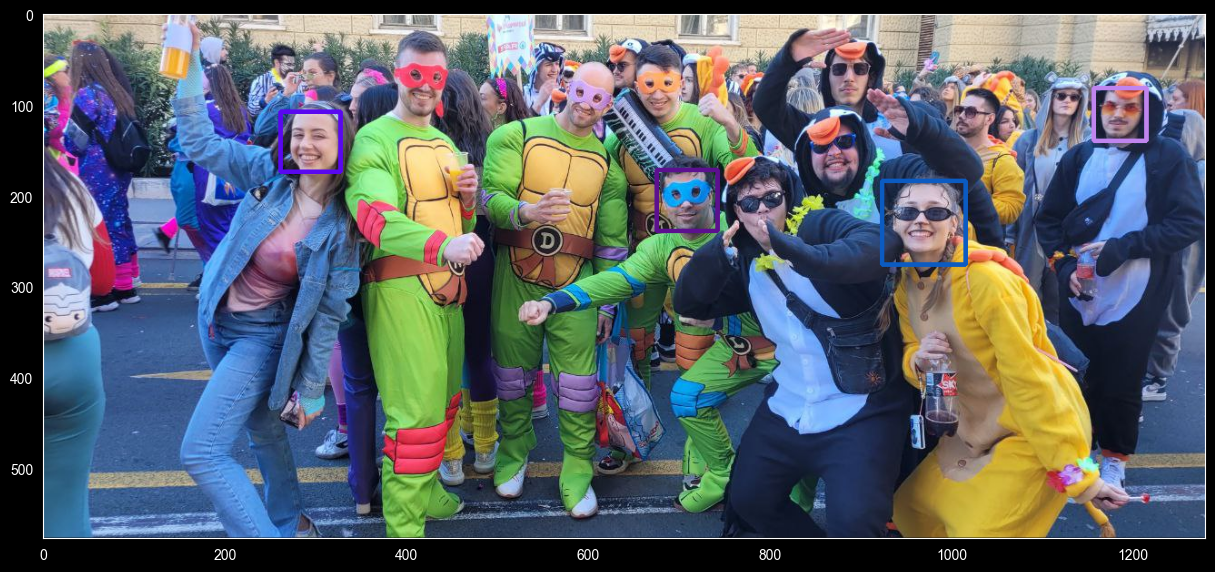

In [7]:
haar_detector = HaarDetector()(karnaval_rgb_img)
result = haar_detector.draw_faces()

plt.imshow(result)
plt.grid(False)


Number of detected faces: 23


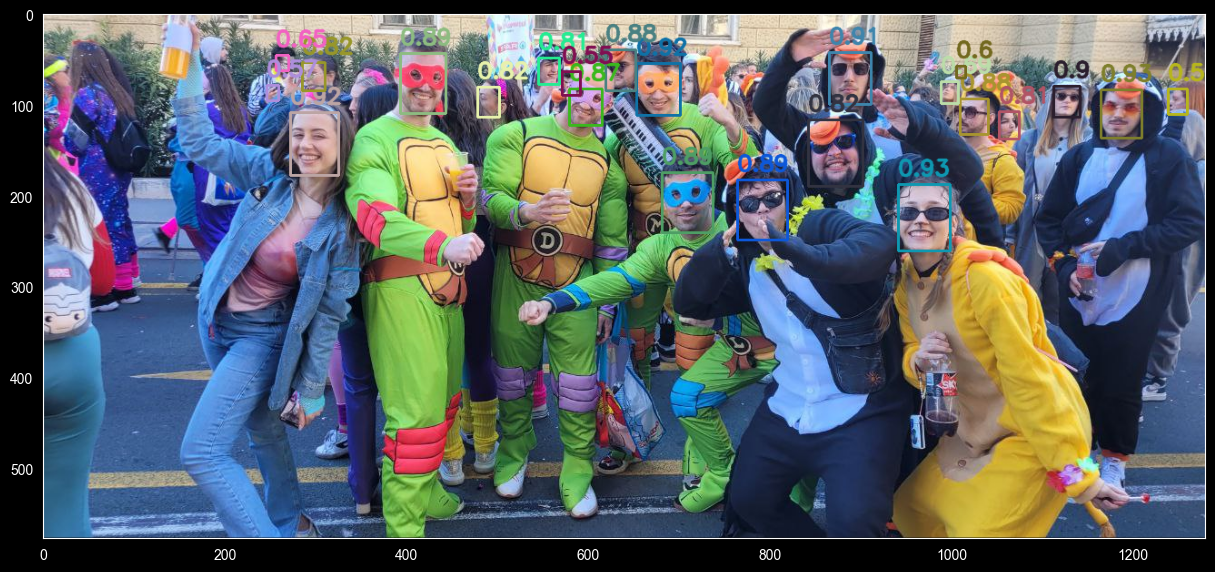

In [8]:
# YuNet Model
yunet_model_path = '../../models/face_detection_yunet_2023mar.onnx'

yunet_detector = YunetFaceDetector(model_path=yunet_model_path)(karnaval_bgr_img)
result = yunet_detector.draw_faces(karnaval_rgb_img)

plt.imshow(result)
plt.grid(False)

Number of detected faces: 12


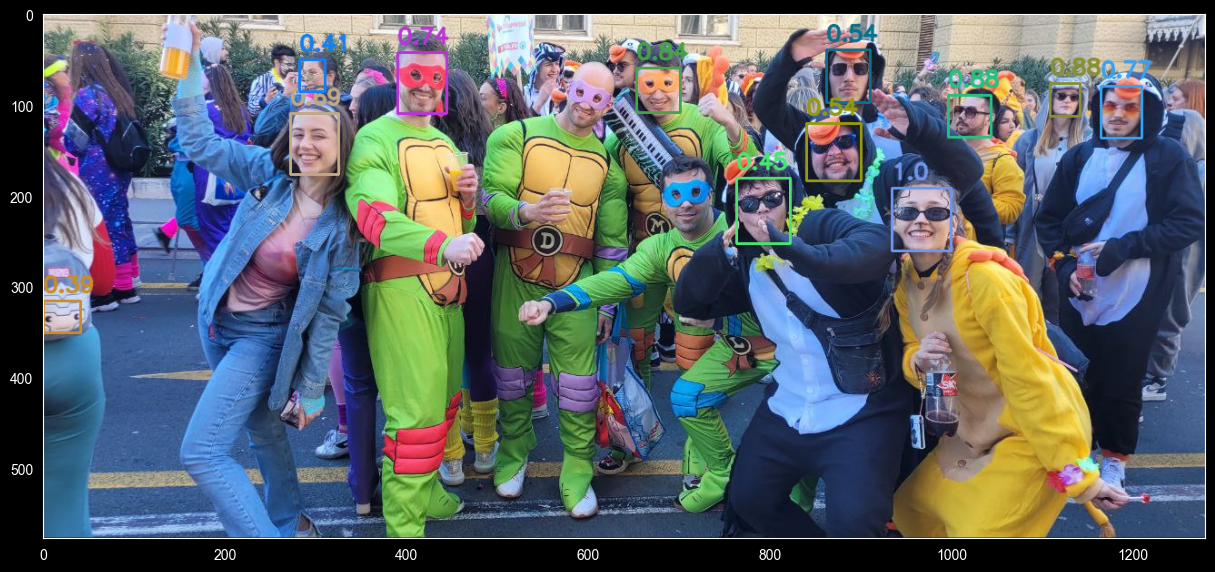

In [13]:
# OpenCVDnn Model
opencv_model_path = '../../models/res10_300x300_ssd_iter_140000_fp16.caffemodel'
opencv_config_path = '../../models/deploy.prototxt'

dnn_detector = OpenCVDnnFaceDetector(model_path=opencv_model_path, config_path=opencv_config_path)(karnaval_bgr_img, conf_threshold=0.3)
result = dnn_detector.draw_faces(karnaval_rgb_img)

plt.imshow(result)
plt.grid(False)

# Resume

| Model                 | Time  | Faces Count | Issue                                                        | Rating |
|-----------------------|-------|-------------|--------------------------------------------------------------|--------|
| HaarDetector          | 720ms | 4           | Weak Detector for simple purpose only.                       | **     |
| YunetFaceDetector     | 752ms | 23          | Perfect !                                                    | *****  |
| OpenCVDnnFaceDetector | 871ms | 12          | Bag Recognized as Human Face, Profile Face is not recognized | ***    |

